In [6]:
import tensorflow as tf
import numpy as np

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
train = (y_train == 0) | (y_train == 1)
test = (y_test == 0) | (y_test == 1)

X_train = X_train[train]
y_train = y_train[train]

X_test = X_test[test]
y_test = y_test[test]

X_train = X_train[..., np.newaxis] / 255.0
X_test = X_test[..., np.newaxis] / 255.0

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, 3, activation="relu", input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [10]:
model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/3
317/317 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9939 - loss: 0.0262 - val_accuracy: 0.9996 - val_loss: 0.0015
Epoch 2/3
317/317 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9987 - loss: 0.0037 - val_accuracy: 0.9968 - val_loss: 0.0069
Epoch 3/3
317/317 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9992 - val_loss: 0.0014


In [11]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9991 - loss: 0.0018    
Test Accuracy: 0.9990543723106384


In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2324s 14us/step


In [13]:
def get_small_data(X, y, n):
    cat = np.where(y.flatten() == 3)[0][:n]
    dog = np.where(y.flatten() == 5)[0][:n]
    idx = np.concatenate([cat, dog])
    return X[idx], (y[idx].flatten() == 5).astype(int)

X_train, y_train = get_small_data(X_train, y_train, 500)
X_test, y_test = get_small_data(X_test, y_test, 100)

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (1000, 32, 32, 3)
Testing: (200, 32, 32, 3)


In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, 3, activation="relu", input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [15]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6237 - loss: 0.6669 - val_accuracy: 0.0000e+00 - val_loss: 0.8501
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6263 - loss: 0.6567 - val_accuracy: 0.0000e+00 - val_loss: 0.9909
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6325 - loss: 0.6477 - val_accuracy: 0.0550 - val_loss: 0.9601
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6388 - loss: 0.6349 - val_accuracy: 0.0900 - val_loss: 0.9791
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6775 - loss: 0.6214 - val_accuracy: 0.1200 - val_loss: 1.0752


In [17]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4950 - loss: 0.7937 
Test Accuracy: 0.4950000047683716


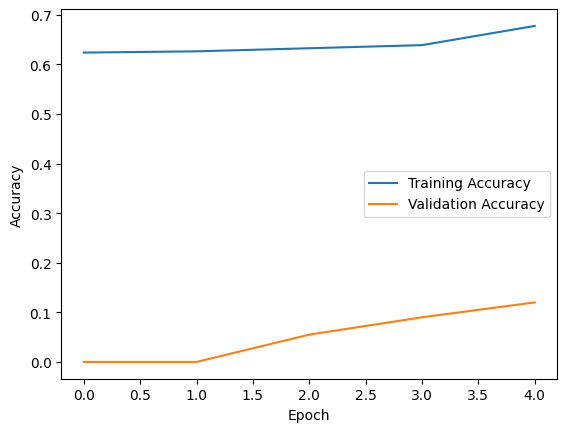

In [18]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


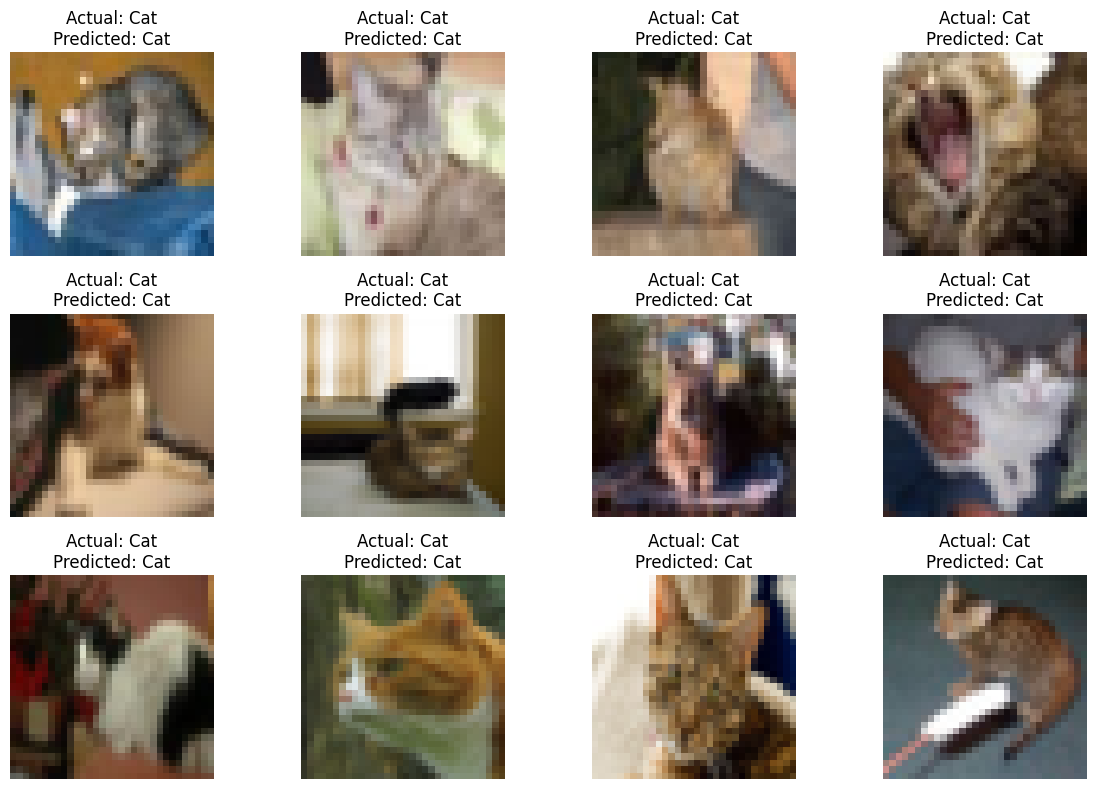

In [19]:
pred = (model.predict(X_test[:12]) > 0.5).astype(int).flatten()

plt.figure(figsize=(12,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i])
    actual = "Dog" if y_test[i] == 1 else "Cat"
    predicted = "Dog" if pred[i] == 1 else "Cat"
    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()